# ABF vs ABF+Fisher--Rao (estimated target) for a WCA dimer

Dimer-in-solvent example from *Free Energy Computations: A Mathematical Perspective*
(Sec. 5.1.5 / 1.3.2.4 / 2.5.2.3). Two particles form a dimer with a double-well bond
in a bath of WCA particles in a periodic box. The reaction coordinate is

$$ z = \frac{|q_1-q_2| - r_0}{2w}, $$

with compact ($z\approx 0$) and stretched ($z\approx 1$) wells separated by a barrier
of height $h$ at $z\approx\tfrac12$. We evolve overdamped Langevin dynamics and compare:

1. **ABF** — adaptive biasing force. A kernel estimator builds $\widehat A_n'(z)\approx F'(z)$
   from local mean forces; the bias potential $B_n(z)=s_n\widehat A_n(z)$ (ramped scale $s_n$)
   flattens the dynamics along $z$.
2. **ABF+FR (estimated target)** — the same ABF dynamics plus a Fisher--Rao birth--death
   step that reallocates replicas along $z$. The FR target marginal is
   $$ q_n(z)\;\propto\;\exp\!\big[-\beta\big(\widehat F^{\mathrm{target}}_n(z)-B_n(z)\big)\big], $$
   where $\widehat F^{\mathrm{target}}_n$ is an **online EMA estimate** of the ABF free energy,
   $\widehat F^{\mathrm{target}}_{n+1}=(1-r)\widehat F^{\mathrm{target}}_n+r\,\widehat A_{n+1}$.
   The score is the log-density ratio $S_i=\log\widehat p_n(Z_i)-\log q_n(Z_i)-\mathrm{KL}(\widehat p_n\|q_n)$,
   with fixed-population birth--death (clip + `max_event_fraction` safeguard).

**The target uses only online simulation quantities.** The thermodynamic-integration (TI)
reference enters **only** in the post-hoc accuracy metrics

$$ \|\widehat F_T-F_{\rm ref}\|_{L^2},\qquad \|\widehat F'_T-F'_{\rm ref}\|_{L^2}, $$

never inside the Fisher--Rao sampler. The FR configuration below was selected by background
hyperparameter tuning on this system.

In [1]:
import math
import os
import time
from dataclasses import dataclass, replace

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

EPS = 1.0e-12


def choose_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = choose_device()
DTYPE = torch.float32
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

torch: 2.12.0+cu130 | CUDA: True
GPU: NVIDIA H200 NVL


## Configuration

`SimConfig` holds the tuned setup. The Fisher--Rao block (`fr_rate`, `fr_every`,
`fr_start_steps`, `target_ema_rate`, `max_event_fraction`, `score_clip`) was selected by
background tuning on this notebook to minimise the final $L^2(F)$ error. ABF and ABF+FR
share every setting except that ABF skips the birth--death step.

In [2]:
@dataclass(frozen=True)
class DimerWCAParams:
    n_dim: int = 10
    a: float = 1.5
    sigma: float = 1.0
    epsilon: float = 1.0
    h: float = 2.0
    w: float = 2.0
    beta: float = 1.0
    min_r: float = 0.65
    force_clip: float = 250.0

    @property
    def n_particles(self):
        return self.n_dim * self.n_dim

    @property
    def box_length(self):
        return self.n_dim * self.a

    @property
    def r0(self):
        return 2.0 ** (1.0 / 6.0) * self.sigma

    @property
    def wca_cutoff(self):
        return self.r0


@dataclass(frozen=True)
class SimConfig:
    n_replicas: int = 1024
    dt: float = 2.0e-3
    n_steps: int = 250_000
    save_every: int = 2500
    seed: int = 42

    z_min: float = -0.2
    z_max: float = 1.2
    n_grid: int = 160

    abf_bandwidth: float = 0.025
    kde_bandwidth: float = 0.070
    abf_smooth_sigma: float = 0.50

    mean_force_sample_clip: float = 500.0
    use_clipped_force_for_mean_force: bool = True
    abf_bias_scale: float = 1.0
    abf_edge_extrapolate: bool = True
    boundary_wall_strength: float = 80.0
    abf_force_clip: float = 40.0
    abf_warmup_steps: int = 10_000
    estimator_burn_in_steps: int = 10_000

    # Fisher-Rao (online estimated target).
    fr_rate: float = 0.2
    score_clip: float = 2.0
    fr_start_steps: int = 20_000
    fr_every: int = 5
    # NEW: online estimated-target knobs.
    target_ema_rate: float = 0.005
    max_event_fraction: float = 0.02

    barrier_center: float = 0.5
    transition_half_width: float = 0.15


@dataclass(frozen=True)
class TIConfig:
    z_min: float = -0.2
    z_max: float = 1.2
    n_z: int = 51
    n_replicas: int = 128
    dt: float = 2.0e-3
    n_thermalization: int = 5_000
    n_steps: int = 50_000
    sample_every: int = 20
    seed: int = 314159
    smooth_sigma: float = 1.0
    z_chunk_size: int = 8

In [3]:
params = DimerWCAParams()
sim = SimConfig(
    n_replicas=1024, n_steps=250_000, save_every=2500, n_grid=160,
    fr_rate=0.1, fr_every=5, fr_start_steps=20_000,
    target_ema_rate=0.005, max_event_fraction=0.02, score_clip=2.0,
)
ti = TIConfig(z_min=sim.z_min, z_max=sim.z_max, dt=sim.dt, z_chunk_size=8)
TI_CACHE = "cache/wca_ti_reference.npz"

print(f"N={params.n_particles}, L={params.box_length:.3f}, r0={params.r0:.6f}, beta={params.beta}")
print(f"replicas={sim.n_replicas}, steps={sim.n_steps}, grid={sim.n_grid}")
print(f"FR: rate={sim.fr_rate}, every={sim.fr_every}, start={sim.fr_start_steps}, "
      f"ema_rate={sim.target_ema_rate}, max_event_fraction={sim.max_event_fraction}, "
      f"score_clip={sim.score_clip}")

N=100, L=15.000, r0=1.122462, beta=1.0
replicas=1024, steps=250000, grid=160
FR: rate=0.1, every=5, start=20000, ema_rate=0.005, max_event_fraction=0.02, score_clip=2.0


## Force engine and geometry

WCA pair forces use a precomputed pair list (all unordered pairs except the dimer `(0,1)`),
batched over replicas. The dimer feels the double-well bond. Geometry helpers give the
reaction coordinate $z$, its gradient, the local mean force
$f(q)=\frac{w}{r}(q_1-q_2)\cdot(\nabla_{q_1}V-\nabla_{q_2}V)-\frac{2w}{\beta r}$
(so $F'(z)=\mathbb{E}[f\mid\xi=z]$), the ABF/wall force injection, lattice initial
conditions, and the constrained projection used by TI.

In [4]:
def as_tensor(x, device=DEVICE, dtype=DTYPE):
    return torch.as_tensor(x, device=device, dtype=dtype)


def wrap_positions(q, L):
    return torch.remainder(q, L)


def minimum_image(delta, L):
    return delta - L * torch.round(delta / L)


def clip_forces(forces, force_clip):
    norm = torch.linalg.norm(forces, dim=-1, keepdim=True)
    scale = torch.clamp(force_clip / torch.clamp(norm, min=EPS), max=1.0)
    return forces * scale


class WCADimerEngine:
    """GPU pair-list force engine for the dimer in WCA solvent."""

    def __init__(self, params, device=DEVICE, dtype=DTYPE):
        self.params = params
        self.device = device
        self.dtype = dtype
        self.N = params.n_particles
        self.L = float(params.box_length)
        self.sigma = float(params.sigma)
        self.epsilon = float(params.epsilon)
        self.h = float(params.h)
        self.w = float(params.w)
        self.r0 = float(params.r0)
        self.cutoff = float(params.wca_cutoff)
        self.min_r = float(params.min_r)

        pair_i, pair_j = torch.triu_indices(self.N, self.N, offset=1, device=device)
        keep = ~((pair_i == 0) & (pair_j == 1))
        self.pair_i = pair_i[keep].long()
        self.pair_j = pair_j[keep].long()
        self.n_pairs = int(self.pair_i.numel())

    def force(self, q, compute_energy=False):
        B = q.shape[0]
        qi = q.index_select(1, self.pair_i)
        qj = q.index_select(1, self.pair_j)
        delta = minimum_image(qi - qj, self.L)
        r = torch.linalg.norm(delta, dim=-1)
        r_safe = torch.clamp(r, min=self.min_r * self.sigma)

        active = r <= self.cutoff
        inv = self.sigma / r_safe
        inv6 = inv ** 6
        inv12 = inv6 ** 2
        dVdr = 4.0 * self.epsilon * (-12.0 * inv12 / r_safe + 6.0 * inv6 / r_safe)
        dVdr = torch.where(active, dVdr, torch.zeros_like(dVdr))
        f_pair = (-dVdr / torch.clamp(r_safe, min=EPS)).unsqueeze(-1) * delta

        forces = torch.zeros_like(q)
        idx_i = self.pair_i.view(1, -1, 1).expand(B, -1, 2)
        idx_j = self.pair_j.view(1, -1, 1).expand(B, -1, 2)
        forces.scatter_add_(1, idx_i, f_pair)
        forces.scatter_add_(1, idx_j, -f_pair)

        d01 = minimum_image(q[:, 0, :] - q[:, 1, :], self.L)
        r01 = torch.linalg.norm(d01, dim=1).clamp_min(EPS)
        u = (r01 - self.r0 - self.w) / self.w
        dVdr_dim = -4.0 * self.h * u * (1.0 - u ** 2) / self.w
        f01 = (-dVdr_dim / r01).unsqueeze(-1) * d01
        forces[:, 0, :] += f01
        forces[:, 1, :] -= f01

        if not compute_energy:
            return forces

        V_wca = 4.0 * self.epsilon * (inv12 - inv6) + self.epsilon
        V_wca = torch.where(active, V_wca, torch.zeros_like(V_wca)).sum(dim=1)
        V_dim = self.h * (1.0 - u ** 2) ** 2
        return V_wca + V_dim, forces


# ---------------------------------------------------------------------------
# Geometry, local mean force, initial conditions
# ---------------------------------------------------------------------------
def dimer_displacement_and_length(q, params):
    d01 = minimum_image(q[:, 0, :] - q[:, 1, :], params.box_length)
    r01 = torch.linalg.norm(d01, dim=1).clamp_min(EPS)
    return d01, r01


def reaction_coordinate(q, params):
    _, r01 = dimer_displacement_and_length(q, params)
    return (r01 - params.r0) / (2.0 * params.w)


def grad_xi_dimer(q, params):
    d01, r01 = dimer_displacement_and_length(q, params)
    grad0 = d01 / (2.0 * params.w * r01[:, None])
    return grad0, -grad0


def local_mean_force(q, physical_forces, params):
    d01, r01 = dimer_displacement_and_length(q, params)
    grad_difference = physical_forces[:, 1, :] - physical_forces[:, 0, :]
    energetic = (params.w / r01) * torch.sum(d01 * grad_difference, dim=1)
    entropic = (2.0 * params.w) / (params.beta * r01)
    return energetic - entropic


def add_abf_force(q, forces, mean_force_at_z, params):
    grad0, grad1 = grad_xi_dimer(q, params)
    out = forces.clone()
    out[:, 0, :] += mean_force_at_z[:, None] * grad0
    out[:, 1, :] += mean_force_at_z[:, None] * grad1
    return out


def add_reaction_coordinate_wall_force(q, forces, z, sim, params):
    if sim.boundary_wall_strength <= 0.0:
        return forces
    upper_excess = torch.clamp(z - sim.z_max, min=0.0)
    lower_excess = torch.clamp(z - sim.z_min, max=0.0)
    dU_wall_dz = sim.boundary_wall_strength * (upper_excess + lower_excess)
    return add_abf_force(q, forces, -dU_wall_dz, params)


def lattice_initial_conditions(params, n_replicas, device=DEVICE, dtype=DTYPE, seed=0, jitter=0.015):
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    coords = [((0.5 + i) * params.a, (0.5 + j) * params.a)
              for i in range(params.n_dim) for j in range(params.n_dim)]
    base = torch.tensor(coords, device=device, dtype=dtype)
    q = base.unsqueeze(0).repeat(n_replicas, 1, 1)
    shifts = torch.rand((n_replicas, 1, 2), device=device, dtype=dtype, generator=g) * params.box_length
    q = wrap_positions(q + shifts, params.box_length)
    if jitter > 0.0:
        q[:, 2:, :] = wrap_positions(
            q[:, 2:, :] + jitter * torch.randn(q[:, 2:, :].shape, device=device, dtype=dtype, generator=g),
            params.box_length,
        )
    q[:, 1, :] = wrap_positions(q[:, 0, :] + torch.tensor([0.0, params.r0], device=device, dtype=dtype), params.box_length)
    return q


def project_dimer_to_z(q, z, params):
    z = torch.as_tensor(z, device=q.device, dtype=q.dtype)
    if z.ndim == 0:
        z = z.expand(q.shape[0])
    target_r = params.r0 + 2.0 * params.w * z
    d01, r01 = dimer_displacement_and_length(q, params)
    direction = d01 / r01[:, None]
    midpoint = q[:, 1, :] + 0.5 * d01
    target_d = target_r[:, None] * direction
    out = q.clone()
    out[:, 0, :] = midpoint + 0.5 * target_d
    out[:, 1, :] = midpoint - 0.5 * target_d
    return wrap_positions(out, params.box_length)

## KDE, ABF estimator, and the estimated-target Fisher--Rao step

`TorchKernelABFEstimator` builds the mean force $\widehat A_n'(z)$ and its integral
$\widehat A_n(z)$. For ABF+FR, `fisher_rao_estimated_target_score_torch` forms the target
$q_n(z)\propto\exp[-\beta(\widehat F^{\rm target}_n-B_n)]$ from the **online EMA estimate**
$\widehat F^{\rm target}_n$ (no TI), computes the log-density-ratio score, and
`fixed_population_birth_death_torch` performs the fixed-population birth--death with the
`max_event_fraction` cap.

In [5]:
def gaussian_kernel_torch(diff, bandwidth):
    bw = float(max(bandwidth, EPS))
    return torch.exp(-0.5 * (diff / bw) ** 2) / (bw * math.sqrt(2.0 * math.pi))


def smooth_profile_torch(y, sigma_grid_points):
    sigma = float(sigma_grid_points)
    if sigma <= 0:
        return y.clone()
    radius = max(1, int(math.ceil(4.0 * sigma)))
    x = torch.arange(-radius, radius + 1, device=y.device, dtype=y.dtype)
    kernel = torch.exp(-0.5 * (x / sigma) ** 2)
    kernel = kernel / kernel.sum()
    yp = F.pad(y.view(1, 1, -1), (radius, radius), mode="replicate")
    return F.conv1d(yp, kernel.view(1, 1, -1)).view(-1)


def cumulative_trapezoid_torch(y, x):
    out = torch.zeros_like(y)
    out[1:] = torch.cumsum(0.5 * (y[1:] + y[:-1]) * (x[1:] - x[:-1]), dim=0)
    return out


def normalize_profile_zero_at_midpoint_torch(profile, grid, midpoint=0.5):
    idx = torch.argmin(torch.abs(grid - midpoint))
    return profile - profile[idx]


def trapz_torch(y, x):
    return torch.sum(0.5 * (y[1:] + y[:-1]) * (x[1:] - x[:-1]))


def normalize_density_on_grid_torch(p_grid, grid, eps=EPS):
    p_grid = torch.clamp(p_grid, min=eps)
    mass = trapz_torch(p_grid, grid)
    return p_grid / torch.clamp(mass, min=eps)


def kde_1d_torch(eval_points, samples, bandwidth, z_min, z_max):
    reflected = torch.cat([samples, 2.0 * z_min - samples, 2.0 * z_max - samples])
    diff = eval_points[:, None] - reflected[None, :]
    p = gaussian_kernel_torch(diff, bandwidth).sum(dim=1) / max(samples.numel(), 1)
    return torch.clamp(p, min=EPS)


def free_energy_from_density_torch(p_grid, grid, beta):
    Fz = -(1.0 / beta) * torch.log(torch.clamp(p_grid, min=EPS))
    return normalize_profile_zero_at_midpoint_torch(Fz, grid)


def mean_force_from_free_energy_torch(free_energy, grid):
    out = torch.empty_like(free_energy)
    out[1:-1] = (free_energy[2:] - free_energy[:-2]) / (grid[2:] - grid[:-2])
    out[0] = (free_energy[1] - free_energy[0]) / (grid[1] - grid[0])
    out[-1] = (free_energy[-1] - free_energy[-2]) / (grid[-1] - grid[-2])
    return out


def interp_uniform_grid(profile, grid, z, outside_value=0.0):
    dz = grid[1] - grid[0]
    x = (z - grid[0]) / dz
    idx0 = torch.floor(x).long()
    inside = (idx0 >= 0) & (idx0 < grid.numel() - 1)
    idx0c = idx0.clamp(0, grid.numel() - 2)
    frac = (x - idx0c.to(z.dtype)).clamp(0.0, 1.0)
    val = (1.0 - frac) * profile[idx0c] + frac * profile[idx0c + 1]
    return torch.where(inside, val, torch.full_like(val, outside_value))


def interp_uniform_grid_edge(profile, grid, z):
    dz = grid[1] - grid[0]
    x = (z - grid[0]) / dz
    idx0 = torch.floor(x).long()
    idx0c = idx0.clamp(0, grid.numel() - 2)
    frac = (x - idx0c.to(z.dtype)).clamp(0.0, 1.0)
    val = (1.0 - frac) * profile[idx0c] + frac * profile[idx0c + 1]
    val = torch.where(z < grid[0], profile[0].expand_as(val), val)
    val = torch.where(z > grid[-1], profile[-1].expand_as(val), val)
    return val


class TorchKernelABFEstimator:
    def __init__(self, z_grid, bandwidth, smooth_sigma=0.0, edge_extrapolate=False):
        self.z_grid = z_grid
        self.bandwidth = float(bandwidth)
        self.smooth_sigma = float(smooth_sigma)
        self.edge_extrapolate = bool(edge_extrapolate)
        self.num = torch.zeros_like(z_grid)
        self.den = torch.zeros_like(z_grid)
        self.n_updates = 0

    def update(self, z_samples, force_samples):
        weights = gaussian_kernel_torch(self.z_grid[:, None] - z_samples[None, :], self.bandwidth)
        self.num += torch.sum(weights * force_samples[None, :], dim=1)
        self.den += torch.sum(weights, dim=1)
        self.n_updates += int(z_samples.numel())

    def mean_force_profile(self):
        raw = self.num / torch.clamp(self.den, min=EPS)
        raw = torch.where(self.den > EPS, raw, torch.zeros_like(raw))
        return smooth_profile_torch(raw, self.smooth_sigma)

    def evaluate(self, z_samples):
        profile = self.mean_force_profile()
        if self.edge_extrapolate:
            return interp_uniform_grid_edge(profile, self.z_grid, z_samples)
        return interp_uniform_grid(profile, self.z_grid, z_samples, outside_value=0.0)

    def pmf_profile(self):
        pmf = cumulative_trapezoid_torch(self.mean_force_profile(), self.z_grid)
        return normalize_profile_zero_at_midpoint_torch(pmf, self.z_grid)


def recentered_clipped_score_torch(raw_score, score_clip):
    score = raw_score - raw_score.mean()
    for _ in range(3):
        score = torch.clamp(score, -score_clip, score_clip)
        score = score - score.mean()
    return torch.clamp(score, -score_clip, score_clip)


def fisher_rao_target_density_estimated_torch(grid, F_target_ema, current_bias_profile, beta, eps=EPS):
    """ESTIMATED-target marginal q_n(z) ~ exp[-beta (F_target_ema(z) - B_n(z))].

    F_target_ema is the ONLINE EMA of the unscaled ABF free energy A_hat_n, and
    B_n = current_bias_profile = abf_scale * A_hat_n. NO TI / oracle input here.
    The additive constant of each profile cancels under normalization, so only the
    *difference* F_target_ema - B_n is physically meaningful.
    """
    if F_target_ema is None:
        raise ValueError("ABF+FR estimated target requires F_target_ema (init at fr_start_steps).")
    if current_bias_profile is None:
        raise ValueError("ABF+FR requires the current ABF bias potential B_n.")
    log_q = -beta * (F_target_ema - current_bias_profile)
    log_q = log_q - torch.max(log_q)
    q_grid = torch.exp(log_q)
    return normalize_density_on_grid_torch(q_grid, grid, eps=eps)


def fisher_rao_estimated_target_score_torch(z_samples, grid, sim, F_target_ema, current_bias_profile, beta, eps=EPS):
    """Simple log-density-ratio FR score against the ESTIMATED target q_n.

    S_i = log p_hat(Z_i) - log q_n(Z_i) - KL(p_hat || q_n), then clip + recenter.
    Returns (score, p_grid, q_grid, kl_pq).
    """
    p_grid = normalize_density_on_grid_torch(
        kde_1d_torch(grid, z_samples, sim.kde_bandwidth, sim.z_min, sim.z_max), grid, eps=eps
    )
    q_grid = fisher_rao_target_density_estimated_torch(
        grid, F_target_ema, current_bias_profile, beta, eps=eps
    )
    p_at = interp_uniform_grid_edge(p_grid, grid, z_samples)
    q_at = interp_uniform_grid_edge(q_grid, grid, z_samples)
    log_ratio_grid = torch.log(torch.clamp(p_grid, min=eps)) - torch.log(torch.clamp(q_grid, min=eps))
    kl_pq = trapz_torch(p_grid * log_ratio_grid, grid)
    raw_score = (
        torch.log(torch.clamp(p_at, min=eps))
        - torch.log(torch.clamp(q_at, min=eps))
        - kl_pq
    )
    score = recentered_clipped_score_torch(raw_score, sim.score_clip)
    return score, p_grid, q_grid, kl_pq


def fixed_population_birth_death_torch(q, score, sim, fr_interval=None):
    """Fixed-population birth-death with a max_event_fraction safeguard.

    Over-represented replicas (positive score) die; each is replaced by a clone of
    an under-represented replica (birth weights ~ max(-S_i, 0)). The number of
    deaths is capped at max_event_fraction * n_replicas (random subselection).
    The whole replica configuration is copied.
    """
    R = q.shape[0]
    score = recentered_clipped_score_torch(score, sim.score_clip)
    interval = sim.fr_every if fr_interval is None else fr_interval
    dt_eff = sim.dt * max(int(interval), 1)

    death_weights = torch.clamp(score, min=0.0)
    birth_weights = torch.clamp(-score, min=0.0)
    death_mass = torch.sum(death_weights)
    birth_mass = torch.sum(birth_weights)
    if bool(((death_mass <= EPS) | (birth_mass <= EPS)).detach().cpu().item()):
        return q.clone(), {"replacement": 0}

    death_prob = torch.where(
        death_weights > 0.0,
        1.0 - torch.exp(-sim.fr_rate * death_weights * dt_eff),
        torch.zeros_like(death_weights),
    )
    death_indices = torch.nonzero(
        torch.rand(R, device=q.device, dtype=q.dtype) < death_prob, as_tuple=False
    ).flatten()
    n_events = int(death_indices.numel())
    if n_events == 0:
        return q.clone(), {"replacement": 0}

    # Safeguard: cap deaths at max_event_fraction * n_replicas (unbiased subselect).
    max_events = int(sim.max_event_fraction * R)
    if max_events >= 1 and n_events > max_events:
        perm = torch.randperm(n_events, device=q.device)[:max_events]
        death_indices = death_indices[perm]
        n_events = max_events

    clone_sources = torch.multinomial(birth_weights, n_events, replacement=True)
    q_new = q.clone()
    q_new[death_indices] = q.index_select(0, clone_sources)
    return q_new, {"replacement": int(n_events)}

## Samplers

`run_sampler_gpu` runs `"abf"` or `"wfr_abf"`. The ABF+FR path keeps `F_target_ema`
separate from the bias $B_n$, seeds it from $\widehat A_n$ when FR starts, then updates it
by EMA each step. **It takes no TI argument.** `run_all_methods_gpu` runs both methods from
one shared initial condition and seed.

In [6]:
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def profile_l2_error_np(profile, reference, grid):
    return math.sqrt(np.trapezoid((np.asarray(profile) - np.asarray(reference)) ** 2, grid) / (grid[-1] - grid[0]))


def align_additive_constant_np(profile, reference, grid):
    profile = np.asarray(profile, dtype=float)
    reference = np.asarray(reference, dtype=float)
    return profile - np.mean(profile - reference)


# ---------------------------------------------------------------------------
# Main sampler (ABF / ABF+FR estimated target). No target_free_energy argument.
# ---------------------------------------------------------------------------
@torch.inference_mode()
def run_sampler_gpu(method, params, sim, engine, initial_q=None, verbose=True):
    """Run ABF (``abf``) or ABF+FR estimated target (``wfr_abf``) on the GPU.

    ABF+FR builds the Fisher-Rao target q_n(z) ~ exp[-beta (F_target_ema(z) - B_n(z))]
    from an ONLINE EMA estimate F_target_ema of the unscaled ABF free energy. The TI
    reference is never used here.
    """
    if method not in {"abf", "wfr_abf"}:
        raise ValueError("method must be 'abf' or 'wfr_abf'")
    torch.manual_seed(sim.seed)
    q = lattice_initial_conditions(params, sim.n_replicas, engine.device, engine.dtype, seed=sim.seed) if initial_q is None else initial_q.clone()
    grid = torch.linspace(sim.z_min, sim.z_max, sim.n_grid, device=engine.device, dtype=engine.dtype)

    bias_estimator = TorchKernelABFEstimator(grid, sim.abf_bandwidth, sim.abf_smooth_sigma, edge_extrapolate=sim.abf_edge_extrapolate)
    production_estimator = TorchKernelABFEstimator(grid, sim.abf_bandwidth, sim.abf_smooth_sigma, edge_extrapolate=sim.abf_edge_extrapolate)
    noise_scale = math.sqrt(2.0 * sim.dt / params.beta)
    total_replacement_events = 0
    F_target_ema = None  # online estimated free-energy target (potential, midpoint-zeroed)

    diag = {k: [] for k in ["steps", "times", "mean_force", "pmf"]}

    t0 = time.perf_counter()
    for step in range(sim.n_steps + 1):
        forces_raw = engine.force(q, compute_energy=False)
        forces_physical = clip_forces(forces_raw, params.force_clip)
        z = reaction_coordinate(q, params)

        current_bias_profile = None
        if method in {"abf", "wfr_abf"}:
            mean_force_input = forces_physical if sim.use_clipped_force_for_mean_force else forces_raw
            f_local = local_mean_force(q, mean_force_input, params)
            f_local = torch.clamp(f_local, -sim.mean_force_sample_clip, sim.mean_force_sample_clip)
            bias_estimator.update(z, f_local)
            if step >= sim.estimator_burn_in_steps:
                production_estimator.update(z, f_local)
            ramp = min(1.0, step / max(sim.abf_warmup_steps, 1))
            abf_scale = sim.abf_bias_scale * ramp
            abf_at_z = abf_scale * torch.clamp(bias_estimator.evaluate(z), -sim.abf_force_clip, sim.abf_force_clip)
            A_hat = bias_estimator.pmf_profile()  # unscaled A_hat_n(z), midpoint-zeroed
            current_bias_profile = abf_scale * A_hat  # B_n(z)
            # Online EMA target, maintained ONLY for wfr_abf, starting at fr_start.
            if method == "wfr_abf" and (step + 1) >= sim.fr_start_steps:
                if F_target_ema is None:
                    F_target_ema = A_hat.clone()
                else:
                    r = sim.target_ema_rate
                    F_target_ema = (1.0 - r) * F_target_ema + r * A_hat
                F_target_ema = normalize_profile_zero_at_midpoint_torch(F_target_ema, grid)
        else:
            abf_at_z = torch.zeros_like(z)

        transport = forces_physical
        if method in {"abf", "wfr_abf"}:
            transport = clip_forces(add_abf_force(q, transport, abf_at_z, params), params.force_clip)
        transport = clip_forces(add_reaction_coordinate_wall_force(q, transport, z, sim, params), params.force_clip)

        if step % sim.save_every == 0 or step == sim.n_steps:
            report_estimator = production_estimator if production_estimator.n_updates > 0 else bias_estimator
            diag["steps"].append(step)
            diag["times"].append(step * sim.dt)
            diag["mean_force"].append(to_numpy(report_estimator.mean_force_profile()))
            diag["pmf"].append(to_numpy(report_estimator.pmf_profile()))

        if step == sim.n_steps:
            break

        q = wrap_positions(q + sim.dt * transport + noise_scale * torch.randn_like(q), params.box_length)
        if method == "wfr_abf":
            next_step = step + 1
            do_fr = (
                next_step >= sim.fr_start_steps
                and (next_step - sim.fr_start_steps) % max(int(sim.fr_every), 1) == 0
            )
            if do_fr:
                z_new = reaction_coordinate(q, params)
                score, p_fr, q_fr, kl_pq = fisher_rao_estimated_target_score_torch(
                    z_new, grid, sim, F_target_ema, current_bias_profile, params.beta
                )
                q, stats = fixed_population_birth_death_torch(q, score, sim, fr_interval=sim.fr_every)
                total_replacement_events += stats["replacement"]

    diag["runtime_seconds"] = time.perf_counter() - t0
    diag["method"] = method
    diag["grid"] = to_numpy(grid)
    diag["total_replacement_events"] = total_replacement_events
    diag["F_target_ema"] = to_numpy(F_target_ema) if F_target_ema is not None else None
    for key in ["steps", "times", "mean_force", "pmf"]:
        diag[key] = np.asarray(diag[key])
    if verbose:
        extra = f", replacements {total_replacement_events}" if method == "wfr_abf" else ""
        print(f"{method:9s}: {diag['runtime_seconds']:.1f}s{extra}")
    return diag


def run_all_methods_gpu(params, sim, engine, methods=("abf", "wfr_abf")):
    initial_q = lattice_initial_conditions(params, sim.n_replicas, engine.device, engine.dtype, seed=sim.seed)
    results = {}
    for method in methods:
        results[method] = run_sampler_gpu(method, params, sim, engine, initial_q=initial_q, verbose=True)
    return results

## Thermodynamic-integration reference (evaluation only)

For each $z_k$ we run constrained dynamics, average the local mean force to get
$F'(z_k)$, and integrate to $F(z)$. **This reference is used only to score the two methods
afterwards; it never enters the Fisher--Rao target.** It is cached to `cache/wca_ti_reference.npz`
and reloaded if the grid matches.

In [7]:
def constrained_ti_reference_gpu(params, sim, ti, engine, eval_grid_np=None, verbose=True):
    torch.manual_seed(ti.seed)
    z_all = torch.linspace(ti.z_min, ti.z_max, ti.n_z, device=engine.device, dtype=engine.dtype)
    mf = torch.zeros(ti.n_z, device=engine.device, dtype=engine.dtype)
    count = torch.zeros(ti.n_z, device=engine.device, dtype=engine.dtype)
    noise_scale = math.sqrt(2.0 * ti.dt / params.beta)

    t0 = time.perf_counter()
    for start in range(0, ti.n_z, ti.z_chunk_size):
        end = min(start + ti.z_chunk_size, ti.n_z)
        z_chunk = z_all[start:end]
        C = z_chunk.numel()
        q0 = lattice_initial_conditions(params, C * ti.n_replicas, engine.device, engine.dtype, seed=ti.seed + start)
        z_batch = z_chunk.repeat_interleave(ti.n_replicas)
        q = project_dimer_to_z(q0, z_batch, params)
        total_steps = ti.n_thermalization + ti.n_steps
        for step in range(total_steps):
            forces_raw = engine.force(q, compute_energy=False)
            transport = clip_forces(forces_raw, params.force_clip)
            q = wrap_positions(q + ti.dt * transport + noise_scale * torch.randn_like(q), params.box_length)
            q = project_dimer_to_z(q, z_batch, params)
            if step >= ti.n_thermalization and (step - ti.n_thermalization) % ti.sample_every == 0:
                sample_forces = engine.force(q, compute_energy=False)
                if sim.use_clipped_force_for_mean_force:
                    sample_forces = clip_forces(sample_forces, params.force_clip)
                f_local = local_mean_force(q, sample_forces, params).view(C, ti.n_replicas)
                mf[start:end] += f_local.sum(dim=1)
                count[start:end] += ti.n_replicas
        if verbose:
            print(f"TI chunk {start:02d}:{end:02d} done, elapsed {(time.perf_counter()-t0)/60:.1f} min")

    mean_force = mf / torch.clamp(count, min=1.0)
    mean_force_smooth = smooth_profile_torch(mean_force, ti.smooth_sigma)
    free_energy = normalize_profile_zero_at_midpoint_torch(cumulative_trapezoid_torch(mean_force_smooth, z_all), z_all)

    if eval_grid_np is None:
        eval_grid = torch.linspace(sim.z_min, sim.z_max, sim.n_grid, device=engine.device, dtype=engine.dtype)
    else:
        eval_grid = torch.as_tensor(eval_grid_np, device=engine.device, dtype=engine.dtype)
    mf_eval = interp_uniform_grid(mean_force_smooth, z_all, eval_grid, outside_value=0.0)
    fe_eval = interp_uniform_grid(free_energy, z_all, eval_grid, outside_value=float(free_energy[0].item()))
    fe_eval = normalize_profile_zero_at_midpoint_torch(fe_eval, eval_grid)
    return {
        "label": "thermodynamic integration reference (evaluation only)",
        "grid": to_numpy(eval_grid),
        "mean_force": to_numpy(mf_eval),
        "free_energy": to_numpy(fe_eval),
        "z_ti": to_numpy(z_all),
        "runtime_seconds": time.perf_counter() - t0,
    }


def load_or_compute_ti_reference(path, params, sim, ti, engine, verbose=True):
    """Load the cached TI reference if grid matches, else compute and cache it.

    EVALUATION ONLY. Never feeds the Fisher-Rao target.
    """
    eval_grid_np = np.linspace(sim.z_min, sim.z_max, sim.n_grid)
    if os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        # float32 storage -> use a float32-safe tolerance on the grid endpoints.
        grid_ok = (d["grid"].shape[0] == sim.n_grid
                   and abs(float(d["grid"][0]) - sim.z_min) < 1e-5
                   and abs(float(d["grid"][-1]) - sim.z_max) < 1e-5)
        if grid_ok:
            if verbose:
                print(f"Loaded cached TI reference from {path}")
            return {"label": str(d["label"]), "grid": d["grid"],
                    "mean_force": d["mean_force"], "free_energy": d["free_energy"], "z_ti": d["z_ti"]}
        if verbose:
            print(f"Cache {path} grid mismatch; recomputing.")
    ref = constrained_ti_reference_gpu(params, sim, ti, engine, eval_grid_np=eval_grid_np, verbose=verbose)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    np.savez(path, label=ref["label"], grid=ref["grid"], mean_force=ref["mean_force"],
             free_energy=ref["free_energy"], z_ti=ref["z_ti"])
    if verbose:
        print(f"Saved TI reference to {path} (runtime {ref['runtime_seconds']/60:.1f} min)")
    return ref


def l2_errors_vs_reference(diag, reference):
    grid = reference["grid"]

## Run: TI reference, then ABF and ABF+FR from a shared initial condition

The TI reference is loaded from cache (or computed once). The two methods then run from the
**same** initial condition and seed, so the only difference is the Fisher--Rao birth--death.

In [8]:
engine = WCADimerEngine(params, DEVICE, DTYPE)
print(f"precomputed WCA pairs: {engine.n_pairs}")

reference = load_or_compute_ti_reference(TI_CACHE, params, sim, ti, engine, verbose=True)

results = run_all_methods_gpu(params, sim, engine, methods=("abf", "wfr_abf"))
print("done:", {k: f"{v['runtime_seconds']:.1f}s" for k, v in results.items()})

precomputed WCA pairs: 4949
Loaded cached TI reference from cache/wca_ti_reference.npz


abf      : 387.9s


wfr_abf  : 449.8s, replacements 4849
done: {'abf': '387.9s', 'wfr_abf': '449.8s'}


## Result: ABF+FR (estimated target) vs ABF

Free energy is defined up to an additive constant, so $\widehat F$ is aligned to the TI
reference by its mean offset before the $L^2$ error is computed. The headline is the final
$L^2(F)$ error; we also report $L^2(F')$.

method                     final L2(F)   final L2(F′)
-----------------------------------------------------
ABF                             0.0874         1.2967
ABF+FR (est. target)            0.0480         1.2934
-----------------------------------------------------
improvement in L2(F)             45.0%
improvement in L2(F′)             0.3%

Lower is better. Free energy aligned by an additive constant before the L2 error.


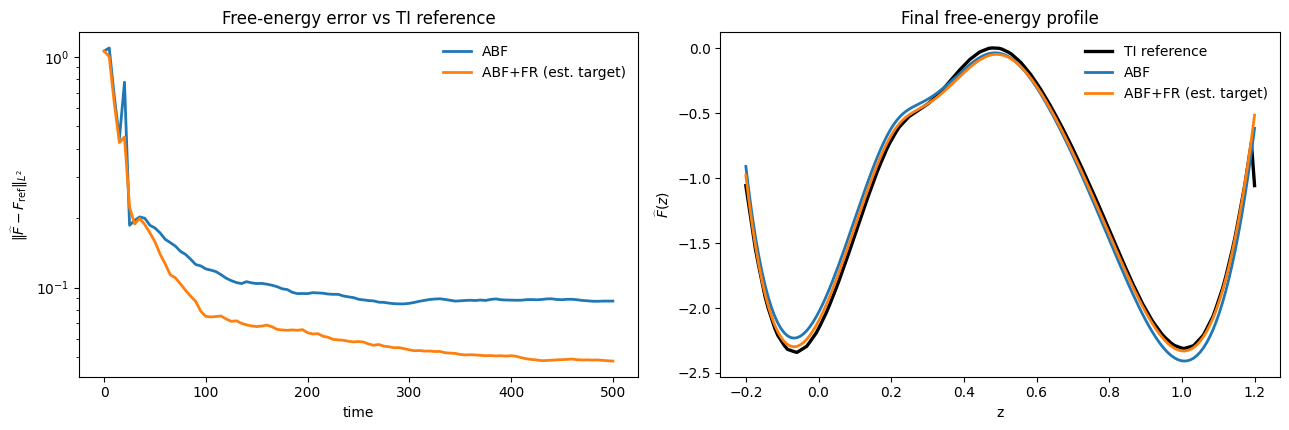

In [9]:
LBL = {"abf": "ABF", "wfr_abf": "ABF+FR (est. target)"}
CLR = {"abf": "tab:blue", "wfr_abf": "tab:orange"}
grid = reference["grid"]


def l2_series(res):
    """Time series of L2(F') and aligned L2(F) against the TI reference."""
    l2_fp = np.array([profile_l2_error_np(p, reference["mean_force"], grid) for p in res["mean_force"]])
    l2_f = np.array([profile_l2_error_np(align_additive_constant_np(p, reference["free_energy"], grid),
                                          reference["free_energy"], grid) for p in res["pmf"]])
    return l2_fp, l2_f


for key in results:
    results[key]["l2_fp"], results[key]["l2_f"] = l2_series(results[key])

abf_f, fr_f = results["abf"]["l2_f"][-1], results["wfr_abf"]["l2_f"][-1]
abf_fp, fr_fp = results["abf"]["l2_fp"][-1], results["wfr_abf"]["l2_fp"][-1]
gain_f = 100.0 * (abf_f - fr_f) / abf_f
gain_fp = 100.0 * (abf_fp - fr_fp) / abf_fp

print(f"{'method':24s}{'final L2(F)':>14s}{'final L2(F′)':>15s}")
print("-" * 53)
print(f"{LBL['abf']:24s}{abf_f:14.4f}{abf_fp:15.4f}")
print(f"{LBL['wfr_abf']:24s}{fr_f:14.4f}{fr_fp:15.4f}")
print("-" * 53)
print(f"{'improvement in L2(F)':24s}{gain_f:13.1f}%")
print(f"{'improvement in L2(F′)':24s}{gain_fp:13.1f}%")
print("\nLower is better. Free energy aligned by an additive constant before the L2 error.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for key in results:
    axes[0].plot(results[key]["times"], results[key]["l2_f"], color=CLR[key], lw=2, label=LBL[key])
axes[0].set_yscale("log")
axes[0].set_title("Free-energy error vs TI reference")
axes[0].set_xlabel("time"); axes[0].set_ylabel(r"$\|\widehat F-F_{\rm ref}\|_{L^2}$")
axes[0].legend(frameon=False)

axes[1].plot(grid, reference["free_energy"], color="black", lw=2.4, label="TI reference")
for key in results:
    fe = align_additive_constant_np(results[key]["pmf"][-1], reference["free_energy"], grid)
    axes[1].plot(grid, fe, color=CLR[key], lw=2, label=LBL[key])
axes[1].set_title("Final free-energy profile")
axes[1].set_xlabel("z"); axes[1].set_ylabel(r"$\widehat F(z)$")
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()